<a href="https://colab.research.google.com/github/andy1680303/machine_learnig_project_2/blob/main/%E6%A9%9F%E5%99%A8%E5%AD%B8%E7%BF%92%E7%A8%8B%E5%BC%8F%E8%A8%AD%E8%A8%88%E5%AF%A6%E5%8B%99_%E6%9C%9F%E6%9C%AB%E5%B0%88%E9%A1%8C%E5%A0%B1%E5%91%8A_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

資料讀取成功！資料維度： (303, 14)
訓練集維度: (242, 20), 測試集維度: (61, 20)
-> RFECV 自動選出的最佳特徵數量: 6 個

-> RFECV (自動選出 6 個最佳特徵) AUC: 0.8788
--- 各模型在優化特徵下的表現 (AUC) ---
[Baseline (DT)] AUC: 0.8788
[Decision Tree (RFECV)] AUC 分數: 0.8642
[Logistic Regression (RFECV)] AUC 分數: 0.9183
[Random Forest (RFECV)] AUC 分數: 0.9237


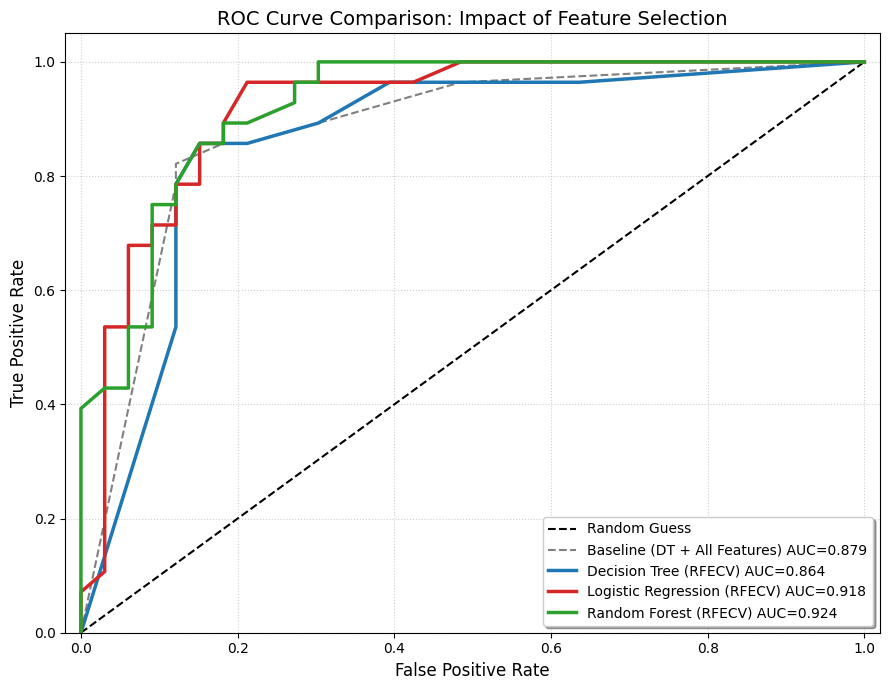

 尋找 [Random Forest (RFECV)] 的最佳門檻值
-> 依據約登指數 (Youden's J) 算出的最佳門檻值: 0.4620
-> 在該門檻值下的 True Positive Rate (敏感度): 0.8929
-> 在該門檻值下的 False Positive Rate (偽陽率): 0.1818


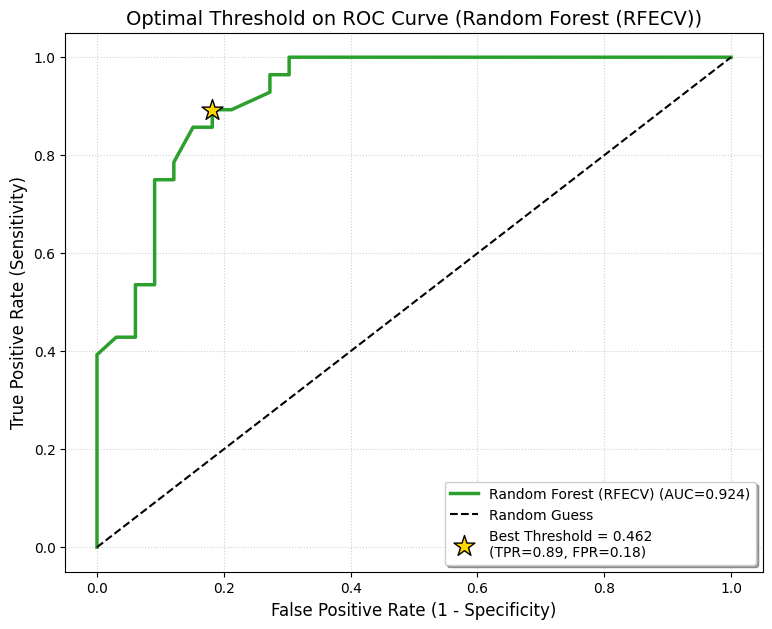


 RFECV 演算法建議保留的最重要特徵：
- sex
- exang
- ca
- cp_4.0
- slope_2.0
- thal_7.0


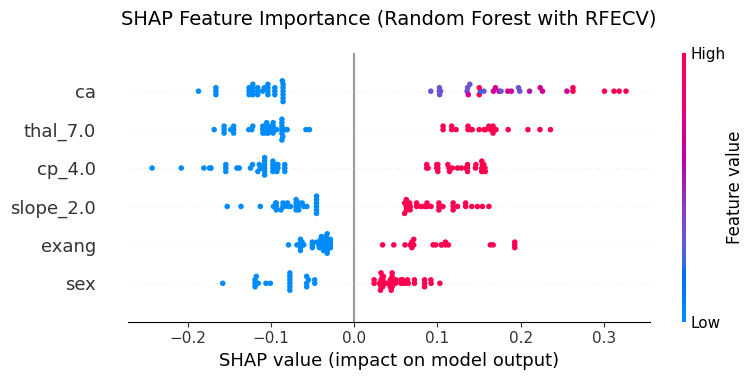

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.metrics import roc_auc_score, roc_curve
import warnings

## 忽略所有警告訊息
warnings.filterwarnings('ignore')

## 1.資料讀取
## 資料來源：https://www.kaggle.com/datasets/hamnawaseem112222222/uci-heart-disease-dataset，並將檔案名稱設定為a.csv
url = "a.csv"
try:
    df = pd.read_csv(url)
    print("資料讀取成功！資料維度：", df.shape)
except FileNotFoundError:
    print("請確認檔案路徑是否正確。以下使用模擬資料結構示意。")
    ## 這裡是避免掉在執行時沒有讀取到檔案的問題

## 2.資料前處理
## 根據資料集描述,'ca'與'thal'欄位會有缺失值。如果讀取進來為'?'時，就先轉為NaN
df = df.replace('?', np.nan)

## 這邊使用KNNImputer填補缺失值，用來避免直接資料直接被丟棄
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

## 這邊是針對類別型變數進行虛擬編碼
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_processed = pd.get_dummies(df_imputed, columns=categorical_cols, drop_first=True)

## 這邊使用了定義特徵矩陣(X)與目標變數(y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

## 這裡是模型訓練中最常用的切分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"訓練集維度: {X_train.shape}, 測試集維度: {X_test.shape}")

## 3.特徵篩選與模型訓練
## 我在這邊使用了 Logistic Regression 作為基底來評估特徵貢獻度
estimator_rfecv = LogisticRegression(max_iter=1000, random_state=42)
selector_rfecv = RFECV(estimator=estimator_rfecv, step=1, cv=5, scoring='roc_auc')
selector_rfecv.fit(X_train, y_train)

## 轉換資料集，只保留有用的特徵
X_train_rfecv = selector_rfecv.transform(X_train)
X_test_rfecv = selector_rfecv.transform(X_test)
print(f"-> RFECV 自動選出的最佳特徵數量: {selector_rfecv.n_features_} 個\n")

## 作為模型的對照組，這裡我先建立了一個使用全部特徵的決策樹
dt_base = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_base.fit(X_train, y_train)
y_proba_dt_base = dt_base.predict_proba(X_test)[:, 1]
auc_dt_base = roc_auc_score(y_test, y_proba_dt_base)

## 建立其餘三個模型 - 分別為決策樹(使用RFECV)、羅吉斯回歸、隨機森林決策樹
models = {
    'Decision Tree (RFECV)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Logistic Regression (RFECV)': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest (RFECV)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}
print(f"-> RFECV (自動選出 {selector_rfecv.n_features_} 個最佳特徵) AUC: {auc_dt_base:.4f}")

## 4.模型評估與視覺化
plt.figure(figsize=(9, 7))
print("--- 各模型在優化特徵下的表現 (AUC) ---")
## 這裡是在繪製隨機猜測線 AUC=0.500
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

## 繪製對照組的ROC曲線
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_dt_base)
plt.plot(fpr_base, tpr_base, label=f'Baseline (DT + All Features) AUC={auc_dt_base:.3f}', color='gray', linestyle='--')
print(f"[Baseline (DT)] AUC: {auc_dt_base:.4f}")

## 設定並繪製其他三個模型的ROC曲線
colors = {
    'Decision Tree (RFECV)': '#1f77b4',       # 質感藍
    'Logistic Regression (RFECV)': '#d62728', # 警示紅
    'Random Forest (RFECV)': '#2ca02c'        # 生態綠
}
for name, model in models.items():
    model.fit(X_train_rfecv, y_train)
    y_pred_proba = model.predict_proba(X_test_rfecv)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"[{name}] AUC 分數: {auc:.4f}")
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} AUC={auc:.3f}', color=colors[name], linewidth=2.5)

## 曲線圖美化
plt.title('ROC Curve Comparison: Impact of Feature Selection', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.yticks(np.arange(0, 1.2, 0.2))
plt.xlim([-0.02, 1.02])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 5.尋找最佳門檻值
## 因為這個程式碼是最後補上，所以比較雜亂
## 這裡我先重新取得隨機森林模型的預測機率
best_model_name = 'Random Forest (RFECV)'
best_model = models[best_model_name]
y_best_proba = best_model.predict_proba(X_test_rfecv)[:, 1]

## 重新計算了FPR,TPR以及對應的門檻值
fpr_best, tpr_best, thresholds = roc_curve(y_test, y_best_proba)

## 利用約登指數計算最佳門檻值
j_scores = tpr_best - fpr_best
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
best_fpr = fpr_best[best_idx]
best_tpr = tpr_best[best_idx]

print(f" 尋找 [{best_model_name}] 的最佳門檻值")
print(f"-> 依據約登指數 (Youden's J) 算出的最佳門檻值: {best_threshold:.4f}")
print(f"-> 在該門檻值下的 True Positive Rate (敏感度): {best_tpr:.4f}")
print(f"-> 在該門檻值下的 False Positive Rate (偽陽率): {best_fpr:.4f}")

## 這裡我另外畫了一張ROC圖表上把這個最佳點標記出來
plt.figure(figsize=(9, 7))
## 畫出剛剛隨機森林的ROC曲線
plt.plot(fpr_best, tpr_best, label=f'{best_model_name} (AUC={roc_auc_score(y_test, y_best_proba):.3f})', color='#2ca02c', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

## 標記出最佳門檻值點 (星星符號)
plt.scatter(best_fpr, best_tpr, color='gold', marker='*', s=250, edgecolor='black', zorder=5,
            label=f'Best Threshold = {best_threshold:.3f}\n(TPR={best_tpr:.2f}, FPR={best_fpr:.2f})')

## 曲線圖美化
plt.title(f'Optimal Threshold on ROC Curve ({best_model_name})', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 預設的predict()是用0.5，現在可以手動用新門檻值分類
y_pred_with_new_threshold = (y_best_proba >= best_threshold).astype(int)

## 印出RFECV最終挑選出的重要特徵名稱
selected_features = X.columns[selector_rfecv.support_]
print("\n RFECV 演算法建議保留的最重要特徵：")
for feat in selected_features:
    print(f"- {feat}")

## 6.利用SHAP套件來證明RFCEV所選出的重要特徵
## 建立TreeExplainer專門用來處理樹狀模型
rf_model = models['Random Forest (RFECV)']
explainer = shap.TreeExplainer(rf_model)

## 這個SHAP值會計算出測試集中每個人、每個特徵的貢獻度
shap_values = explainer.shap_values(X_test_rfecv)

## 這邊我比較關心預測生病的貢獻度，因此取[..., 1]或 index 1。
if isinstance(shap_values, list):
    # 舊版 shap 輸出為 list
    shap_obj = shap_values[1]
else:
    # 新版 shap 輸出可能是 3D 陣列 (樣本數, 特徵數, 類別數)
    shap_obj = shap_values[..., 1] if len(shap_values.shape) == 3 else shap_values

## 視覺化，繪製 Summary Plot
plt.figure(figsize=(10, 6))
## 為了讓圖表顯示正確的特徵名稱，我們要把被 RFECV 保留的特徵名稱傳進去
selected_feature_names = X.columns[selector_rfecv.support_]

shap.summary_plot(shap_obj, X_test_rfecv, feature_names=selected_feature_names, show=False)
plt.title("SHAP Feature Importance (Random Forest with RFECV)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()



In [ ]:
## 由上面的隨機森林模型我做了一個心臟病預測風險系統
print("歡迎使用心臟病風險預測系統 (基於 RandomForest - RFECV 最佳特徵)")
print("請依照提示，依序輸入病患的生理數據：\n")
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_rfecv, y_train)

## 1.這邊是透過input()取得使用者輸入的生理指標，並強制轉換為適當的數值型別
try:
    age = float(input("1. 年齡 (age, 最大值為130: "))
    sex = int(input("2. 性別 (sex, 1=男性, 0=女性): "))
    cp = int(input("3. 胸痛類型 (cp, 1=典型, 2=非典型, 3=非心絞痛, 4=無症狀): "))
    trestbps = float(input("4. 靜止血壓 (trestbps, mm Hg) [例如 130]: "))
    chol = float(input("5. 膽固醇 (chol, mg/dl) [例如 250]: "))
    fbs = int(input("6. 空腹血糖是否>120 (fbs, 1=是, 0=否): "))
    restecg = int(input("7. 靜止心電圖結果 (restecg, 0=正常, 1=異常, 2=左室肥大): "))
    thalach = float(input("8. 最高心率 (thalach) [例如 150]: "))
    exang = int(input("9. 運動引起心絞痛 (exang, 1=是, 0=否): "))
    oldpeak = float(input("10. 運動相對靜止的ST壓低 (oldpeak) [例如 1.5]: "))
    slope = int(input("11. ST峰值斜率 (slope, 1=上斜, 2=平坦, 3=下斜): "))
    ca = float(input("12. 螢光透視染色的主要血管數 (ca, 0-3): "))
    thal = int(input("13. 地中海貧血 (thal, 3=正常, 6=固定缺陷, 7=可逆缺陷): "))

    ## 2.資料轉型與前處理
    ## 把輸入的資料建立成字典
    user_data = {
        'age': [age],
        'sex': [sex],
        'cp': [cp],
        'trestbps': [trestbps],
        'chol': [chol],
        'fbs': [fbs],
        'restecg': [restecg],
        'thalach': [thalach],
        'exang': [exang],
        'oldpeak': [oldpeak],
        'slope': [slope],
        'ca': [ca],
        'thal': [thal]
    }

    ## 3.將字典轉成DataFrame的形式
    user_df = pd.DataFrame(user_data).astype(float)

    ## 4.進行與訓練集相同的類別變數虛擬編碼
    categorical_cols = ['cp', 'restecg', 'slope', 'thal']
    user_processed = pd.get_dummies(user_df, columns=categorical_cols)

    ## 5.把欄位對齊，並確保輸入資料的特徵維度與原訓練集X完全相同，缺少的欄位會自動補上0
    user_aligned = user_processed.reindex(columns=X.columns, fill_value=0)

    ## 6.特徵篩選轉換
    ## 將新資料沒入選的最佳特徵移除
    user_rfecv = selector_rfecv.transform(user_aligned)

    ## 7.進行預測，以取得判定為1(有病)的機率
    risk_prob = rf_model.predict_proba(user_rfecv)[0][1]

    ## 若預測值大於最佳門檻值，則有病；反之
    if risk_prob >= best_threshold:
        prediction = 1
    else:
        prediction = 0

    print("系統分析完成，預測結果出爐：")
    print(f"該病患的罹病機率估計為：{risk_prob * 100:.2f}%")

    if prediction == 1: ## 目標值Target:1=Heart Disease
        print("系統判定：高風險(可能患有心臟病)！")
        print("建議：請盡速安排專業醫師進一步檢查。")
    else:               ## 目標值Target:0=No Heart Disease
        print("系統判定：低風險(心臟病機率較低)。")
        print("建議：請繼續保持良好的生活習慣！")
except ValueError:
    print("\n錯誤：請確認您輸入的格式是否正確！(必須填寫數字)")

歡迎使用心臟病風險預測系統 (基於 RandomForest - RFECV 最佳特徵)
請依照提示，依序輸入病患的生理數據：

1. 年齡 (age, 最大值為130: 60
2. 性別 (sex, 1=男性, 0=女性): 1
3. 胸痛類型 (cp, 1=典型, 2=非典型, 3=非心絞痛, 4=無症狀): 4
4. 靜止血壓 (trestbps, mm Hg) [例如 130]: 200
5. 膽固醇 (chol, mg/dl) [例如 250]: 280
6. 空腹血糖是否>120 (fbs, 1=是, 0=否): 1
7. 靜止心電圖結果 (restecg, 0=正常, 1=異常, 2=左室肥大): 2
8. 最高心率 (thalach) [例如 150]: 110
9. 運動引起心絞痛 (exang, 1=是, 0=否): 1
10. 運動相對靜止的ST壓低 (oldpeak) [例如 1.5]: 0.8
11. ST峰值斜率 (slope, 1=上斜, 2=平坦, 3=下斜): 3
12. 螢光透視染色的主要血管數 (ca, 0-3): 2
13. 地中海貧血 (thal, 3=正常, 6=固定缺陷, 7=可逆缺陷): 7
系統分析完成，預測結果出爐：
該病患的罹病機率估計為：96.20%
系統判定：高風險(可能患有心臟病)！
建議：請盡速安排專業醫師進一步檢查。
